In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [9]:
datasets = {
    "fund_master": fund_master,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "perf": perf,
    "txn": txn,
    "portfolio": portfolio,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)


fund_master
(40, 15)

nav
(46000, 3)

aum
(90, 5)

sip
(48, 6)

category
(144, 3)

folio
(21, 6)

perf
(40, 19)

txn
(32778, 13)

portfolio
(322, 8)

benchmark
(8050, 3)


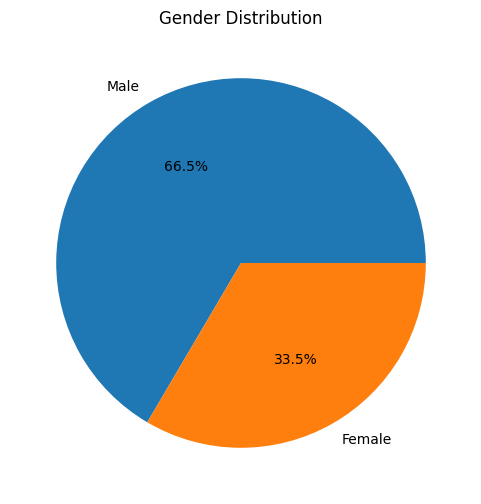

In [10]:
gender_counts = txn['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

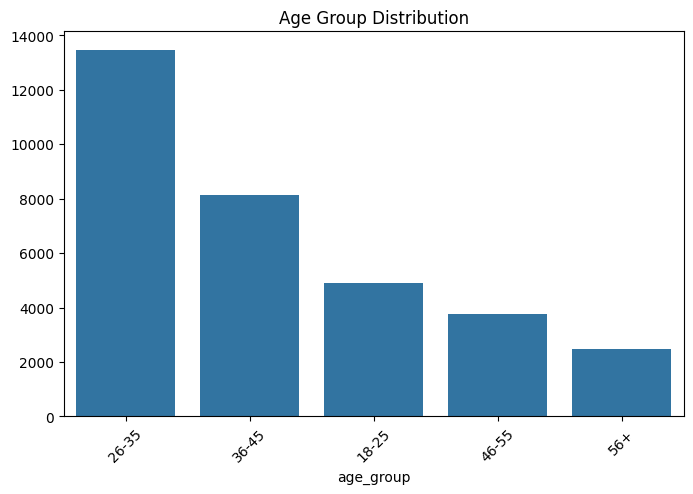

In [11]:
age_counts = txn['age_group'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.title("Age Group Distribution")
plt.xticks(rotation=45)
plt.show()

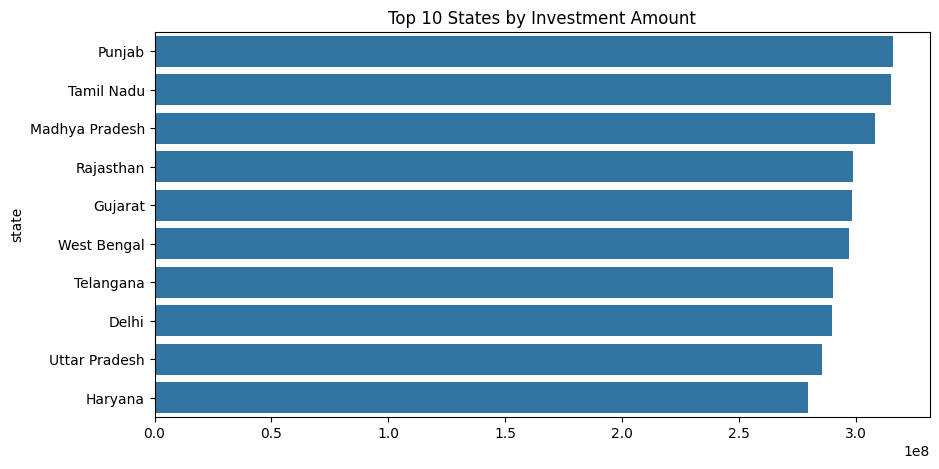

In [12]:
state_amount = txn.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_amount.values, y=state_amount.index)
plt.title("Top 10 States by Investment Amount")
plt.show()

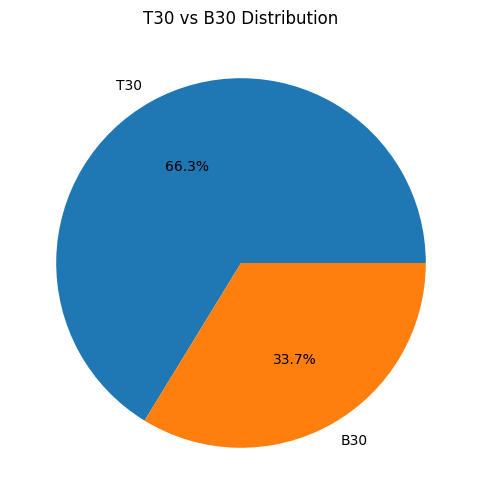

In [13]:
tier_counts = txn['city_tier'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%')
plt.title("T30 vs B30 Distribution")
plt.show()

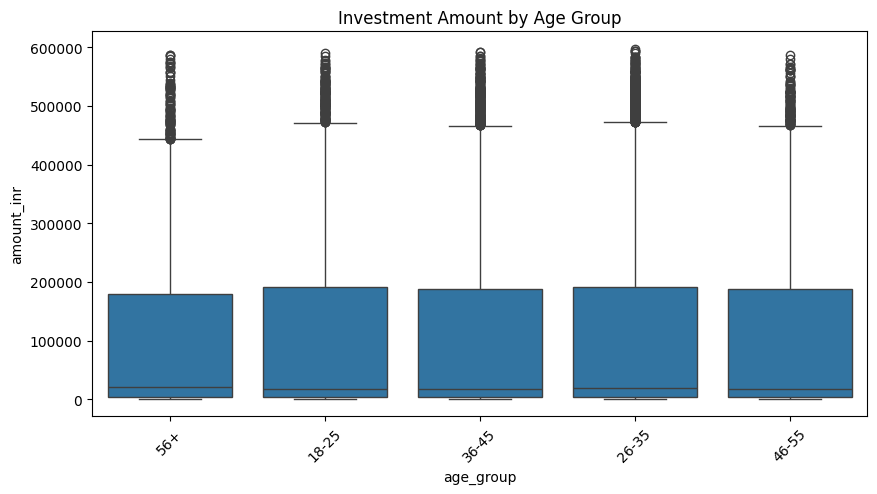

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(data=txn, x='age_group', y='amount_inr')
plt.title("Investment Amount by Age Group")
plt.xticks(rotation=45)
plt.show()

In [15]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [16]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


1. Male and female participation shows a diversified investor base.
2. Investment activity varies significantly across age groups.
3. Top states contribute a major share of total investment flows.
4. City tier distribution highlights penetration beyond major metros.
5. Investment amounts differ across investor demographics.
6. AUM is concentrated among leading fund houses.
7. SIP inflows demonstrate long-term participation trends.
8. Folio counts indicate growing mutual fund adoption.
9. Scheme performance varies across categories.
10. Sector allocation reflects portfolio diversification.

In [17]:
print(txn.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
